In [1]:
import uproot
import vector
import hist
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from sidm.tools import sidm_processor, utilities

import mplhep as hep
plt.style.use(hep.style.CMS)

### Open the Run3 file

In [2]:
file_path = "root://xcache//store/user/lpcmetx/SIDM/ULSignalSamples/2024/nanoaodYear2024.root"
# The file root://xcache//store/user/lpcmetx/SIDM/ULSignalSamples/2024/nanoaodYear2024.root is a 
# 500 GeV bound state with two 5 GeV dark photons both decaying to muons  
temp_file = uproot.open(file_path)

for key in temp_file:
    print(key)

tree = temp_file['Events']

#Load all the branches into memory and store in the "arrays" dictionary (this is slow)
arrays =  tree.arrays()

tag;1
Events;1
LuminosityBlocks;1
Runs;1
MetaData;1
ParameterSets;1


### Define masks for different types of particles

In [3]:
#Dark photons
gen_dp_mask = abs(arrays["GenPart_pdgId"]) == 32

#Bound state
gen_bs_mask = abs(arrays["GenPart_pdgId"]) == 35

#Final state muons
gen_mu_mask = (abs(arrays["GenPart_pdgId"])  == 13) &  (arrays["GenPart_status"] == 1)

#Final state electrons
gen_ele_mask = abs(arrays["GenPart_pdgId"]) == 11 &  (arrays["GenPart_status"] == 1)

#Make a 4-vector for the GenParticles    
gen = vector.zip({"eta": arrays['GenPart_eta'],
                          "mass": arrays['GenPart_mass'],
                          "phi": arrays['GenPart_phi'],
                            "pt": arrays['GenPart_pt']})

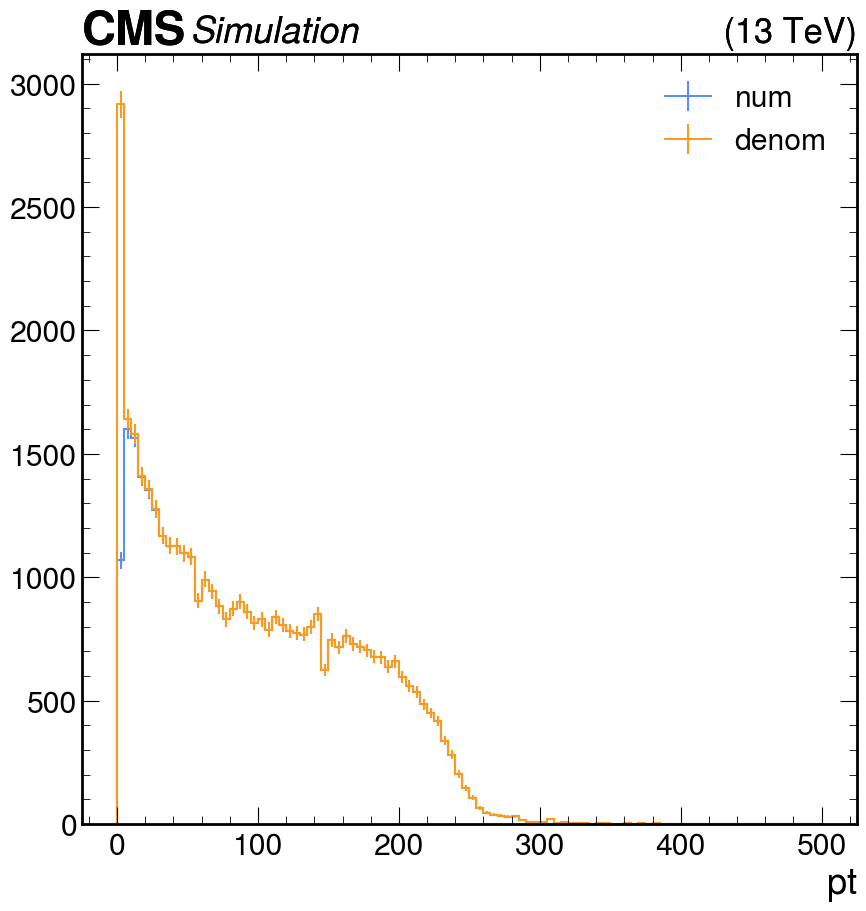

In [4]:
#Define the histograms and the axis
pt_axis = hist.axis.Regular(100, 0, 500, name="pt")
numerator = hist.Hist(pt_axis)
denominator = hist.Hist(pt_axis)

#Fill the histograms with the flattened arrays
numerator.fill(ak.flatten(gen.pt[gen_mu_mask & (abs(gen.eta) < 2.5)]))
denominator.fill(ak.flatten(gen.pt[gen_mu_mask]))

#Plot both on the same figure
utilities.plot(numerator, label = "num")
utilities.plot(denominator, label ="denom")
plt.legend(loc = 'upper right')

/home/cms-jovyan/SIDM_forks_2025/trigger/SIDM/sidm/tools/utilities.py:158: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/SIDM_forks_2025/trigger/SIDM/sidm/tools/utilities.py:163: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/SIDM_forks_2025/trigger/SIDM/sidm/tools/utilities.py:164: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()


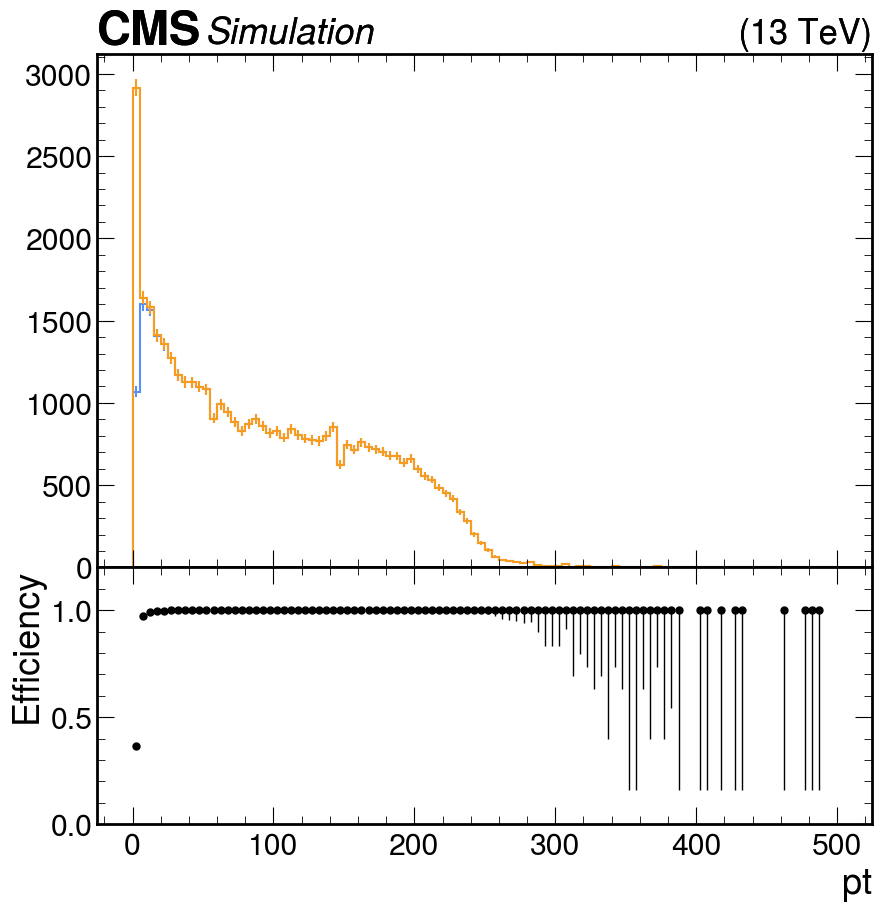

In [5]:
#Plot both along with their ratio. The warnings occur if there are any bins with zero counts and can be safely ignored. 
#If the numerator is ever greater than the denominator in any bin, this will throw an error
utilities.plot_ratio(numerator,denominator)